# COMP 432 Project

Team members: Sean Meath 40175293, 

Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import sklearn
import os
import cv2

from torchvision import datasets
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from PIL import Image
from pathlib import Path

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\torchvision\io\image.py:11: UserWarning: Failed to load image Python extension: Could not find module 'A:\ProgrammingStuff\Other\Anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warn(f"Failed to load image Python extension: {e}")


Temporary Use of EMNIST Dataset:

In [2]:
train_data = datasets.EMNIST(
    root = 'data',
    split = 'balanced',
    train = True,                         
    transform = ToTensor(), 
    download = True,            
)
test_data = datasets.EMNIST(
    root = 'data', 
    split = 'balanced',
    train = False, 
    transform = ToTensor()
)

loaders = {
    'train' : torch.utils.data.DataLoader(train_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : torch.utils.data.DataLoader(test_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}

Dataset Creation: https://stackoverflow.com/questions/66711654/converting-image-into-mnist-format
                  https://github.com/gskielian/JPG-PNG-to-MNIST-NN-Format/blob/master/convert-images-to-mnist-format.py
                  https://www.youtube.com/watch?v=iwoLAj-SZ80

Shape:  torch.Size([1, 1, 28, 28])  Data Type: torch.float32
Shape:  torch.Size([1, 1, 28, 28])  Data Type: torch.float32


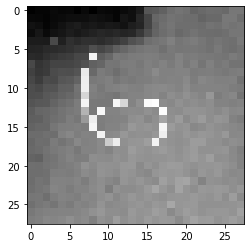

In [40]:
#Get Image Directory
cwd = Path.cwd()
imgdir = os.path.join(cwd, 'img')

#List of Images (to fill)
images = torch.zeros(2, 1, 28, 28)

for filename in os.listdir(imgdir):
    filepath = os.path.join(imgdir, filename)
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_LINEAR)
    img_resized = cv2.bitwise_not(img_resized)
    img_resized = np.copy(img_resized).reshape(1, 1,28,28)
    plt.imshow(img_resized.squeeze(), cmap="gray");
    img_resized = torch.tensor(img_resized, dtype=torch.float32)
    print('Shape: ', np.shape(img_resized), ' Data Type:', img_resized.dtype)

EMNIST Dataset Visualization:

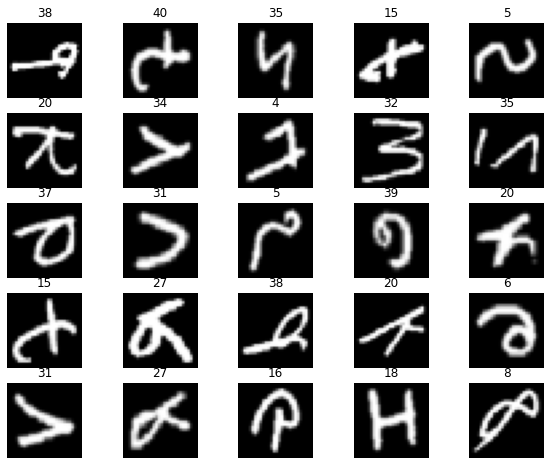

In [4]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Logistic Regression: https://jovian.ai/fonzi956/03-logistic-regression-emnist

not working

In [5]:
#input_size = 28*28
#num_classes = 47

#class LinearModel(nn.Module):
#    def __init__(self):
#        super().__init__()
#        self.linear = nn.Linear(input_size, num_classes)
#        
#    def forward(self, xb):
#        xb = xb.reshape(-1, 784)
#        out = self.linear(xb)
#        return out
    
#linear = LinearModel()
#loss_func = F.cross_entropy
#optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [ ]:
datafile = images
mat = scipy.io.loadmat(datafile)
X = mat['X']
y = mat['y']

num_labels = 10 # There are 10 labels/classes (0 to 9)

reg_param = 0.1 

In [ ]:
for i in range(num_labels):
  print("Optimizing parameters for digit" ,i)

  y_bool = np.matrix([1 if label == i else 0 for label in y])

  updated_theta = scipy.optimize.fmin_cg(costFunction, fprime = gradientDescent, x0 = initial_theta, args = (X, y, reg_param), maxiter = 50)

In [ ]:
h_max = sigmoid(X.dot(updated_theta.T))

for i in range(1, m):
  max_prob = numpy.argmax(h_max[i-1, :])
  p[i-1] = max_prob

In [ ]:
for j in range(m):
  if(p[i] == y[i]):
    num_correct = num_correct + 1

accuracy = (num_correct / m) * 100

Logistic Regression Training:

In [6]:
#num_epochs = 10

#def train(num_epochs, linear, loaders):
#    linear.train()
        
    # Train the model
#    total_step = len(loaders['train'])
        
#    for epoch in range(num_epochs):
#        for i, (images, labels) in enumerate(loaders['train']):
            
            # gives batch data, normalize x when iterate train_loader
#            b_x = Variable(images)   # batch x
#            b_y = Variable(labels)   # batch y
#            output = linear(b_x)[0]
#            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
#            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
#            loss.backward()                # apply gradients             
#            optimizer.step()                
            
#            if (i+1) % 100 == 0:
#                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
#                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
                
#train(num_epochs, linear, loaders)

Logistic Regression 2: Keep until other works

In [7]:
#from sklearn.linear_model import LogisticRegression

#model = LogisticRegression(max_iter=1000)

#model.fit(X_train_em_re, y_train_em)

In [8]:
#print(f"{((1 - model.score(X_train_em_re, y_train_em)) * 100):.2f}% training error")
#print(f"{((1 - model.score(X_test_em_re, y_test_em)) * 100):.2f}% testing error")

Rough Version For CNN (From Lab 4)

In [9]:
torch.manual_seed(0) # Ensure model weights initialized with same random numbers

num_filters = 8
filter_size = 5
pool_size = 2

# Your code here. Aim for 9-10 lines.
model = torch.nn.Sequential(
    # Your code for defining the model architecture here. Aim for 5-9 lines.
    torch.nn.Conv2d(1, num_filters, filter_size, 1, 2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(filter_size*filter_size),
    torch.nn.Flatten(),
    torch.nn.Linear(num_filters*1, 10)
)

y_pred = model(img_resized)
print(y_pred)

tensor([[  1.5195,  55.7014, -47.6539,  37.7607, -32.7990, -36.6646, -27.3094,
         -13.2822, -43.5870, -39.9252]], grad_fn=<AddmmBackward0>)


CNN Definition: https://medium.com/@nutanbhogendrasharma/pytorch-convolutional-neural-network-with-mnist-dataset-4e8a4265e118

to be modified but it works

In [10]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.out = nn.Linear(32 * 7 * 7, 47)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        output = self.out(x)
        return output, x

cnn = CNN()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr = 0.01)

CNN Training:

In [11]:
from torch.autograd import Variable

num_epochs = 10

def train(num_epochs, cnn, loaders):
    cnn.train()
        
    # Train the model
    total_step = len(loaders['train'])
        
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):
            
            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)
            b_y = Variable(labels)
            output = cnn(b_x)[0]               
            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
            loss.backward()           
            optimizer.step()
            
            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

train(num_epochs, cnn, loaders)

Epoch [1/10], Step [100/1128], Loss: 0.9260
Epoch [1/10], Step [200/1128], Loss: 0.6927
Epoch [1/10], Step [300/1128], Loss: 0.5854
Epoch [1/10], Step [400/1128], Loss: 0.6744
Epoch [1/10], Step [500/1128], Loss: 0.7476
Epoch [1/10], Step [600/1128], Loss: 0.5319
Epoch [1/10], Step [700/1128], Loss: 0.7026
Epoch [1/10], Step [800/1128], Loss: 0.8232
Epoch [1/10], Step [900/1128], Loss: 0.5743
Epoch [1/10], Step [1000/1128], Loss: 0.3505
Epoch [1/10], Step [1100/1128], Loss: 0.6888
Epoch [2/10], Step [100/1128], Loss: 0.5699
Epoch [2/10], Step [200/1128], Loss: 0.4466
Epoch [2/10], Step [300/1128], Loss: 0.7443
Epoch [2/10], Step [400/1128], Loss: 0.6484
Epoch [2/10], Step [500/1128], Loss: 0.8462
Epoch [2/10], Step [600/1128], Loss: 0.4522
Epoch [2/10], Step [700/1128], Loss: 0.4523
Epoch [2/10], Step [800/1128], Loss: 0.5642
Epoch [2/10], Step [900/1128], Loss: 0.5003
Epoch [2/10], Step [1000/1128], Loss: 0.5826
Epoch [2/10], Step [1100/1128], Loss: 0.8208
Epoch [3/10], Step [100/1128

In [35]:
test_output, last_layer = cnn(img_resized)
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction class: {pred_y}')

Prediction class: 11


In [41]:
sample = next(iter(loaders['test']))
imgs, lbls = sample
actual_number = lbls[:10].numpy()

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')

Prediction number: [41 38 10 31 23 36 10  1 40 18]
Actual number: [44 38 10 30 23 26 10  1 40 18]
